In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [10]:
I = 6.35*10**-6
idisk = 0.00000253
print(I)
for x in range(5):
    print(f"{I+(idisk*((x*2)+1))}")

6.349999999999999e-06
8.88e-06
1.3939999999999999e-05
1.8999999999999998e-05
2.4059999999999997e-05
2.912e-05


In [52]:
disk = 1.33 * 10**-8
d = 1.27* 10**-8
error = []
error.append(math.sqrt((disk**2)))
for x in range(5):
    error.append(math.sqrt((disk**2) + (((x*2)+1)*d)**2))
    

In [53]:
print(error)

[1.3300000000000002e-08, 1.838967101391431e-08, 4.035467754796215e-08, 6.487788529229356e-08, 8.988937645795526e-08, 1.1507119535313781e-07]


In [76]:
t2 = [1.59,2.35,4.15,6.08,7.40,9.47]
terror = [0.09,
0.08,
0.17,
0.17,
0.15,
0.11]


Ilist = [6.35*10**-6,
8.88*10**-6,
1.39*10**-5,
1.90*10**-5,
2.41*10**-5,
2.91*10**-5]
p, v = np.polyfit(t2, Ilist, 1, cov=True)
m = p[0]
c = p[1]
e = np.sqrt(v[0, 0])



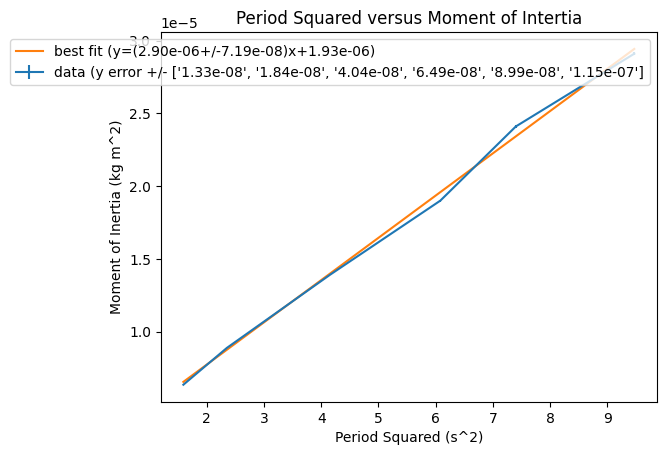

In [81]:
f = [f"{x:.2e}" for x in error]
plt.errorbar(t2, Ilist, yerr=error, label = f"data (y error +/- {f}")
calc = [m*x + b for x in t2]
plt.plot(t2, calc, label = f"best fit (y=({m:.2e}+/-{np.sqrt(v[0, 0]):.2e})x+{b:.2e})")
plt.title("Period Squared versus Moment of Intertia")
plt.xlabel("Period Squared (s^2)")
plt.ylabel("Moment of Inertia (kg m^2)")
plt.legend(loc = "upper right")

In [56]:
error2 = [m*x for x in error]
print(error)
print(error2)
print(m)
ar = [math.sqrt((error[x]**2)+(error2[x]**2)) for x in range(6)]
print(ar)

[1.3300000000000002e-08, 1.838967101391431e-08, 4.035467754796215e-08, 6.487788529229356e-08, 8.988937645795526e-08, 1.1507119535313781e-07]
[np.float64(3.862257860425568e-14), np.float64(5.3402745431677255e-14), np.float64(1.1718809816883908e-13), np.float64(1.884023476977061e-13), np.float64(2.6103454946878995e-13), np.float64(3.34161375008438e-13)]
2.9039532785154642e-06
[1.3300000000056081e-08, 1.8389671013991848e-08, 4.0354677548132304e-08, 6.487788529256711e-08, 8.988937645833428e-08, 1.15071195353623e-07]


In [60]:
error2 = [m*x for x in terror]

ar = [math.sqrt((error[x]**2)+(error2[x]**2)) for x in range(6)]
for x in range(6):
    print(ar[x])

2.6169398467443946e-07
2.3304296968654638e-07
4.953186855003965e-07
4.979169009039969e-07
4.447711259575154e-07
3.395291006526372e-07


In [66]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 6.4 MB/s  0:00:016.2 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 22.3 MB/s  0:00:00.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [statsmodels] 5/6 [statsmodels]laic]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [67]:
import statsmodels.api as sm
data_new = sm.add_constant(t2)
weights = [1/(x**2) for x in ar]
wls_model = sm.WLS(Ilist, data_new, weights=weights)
wls_results = wls_model.fit()


0.00011418692800819505
2.1109493887114886e-06


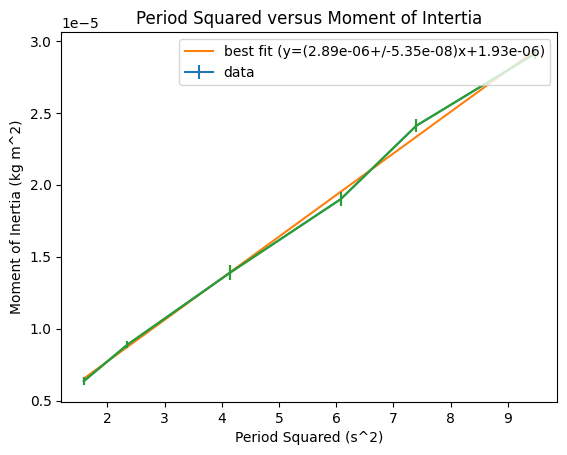

In [96]:
b = wls_results.params[0]
m = wls_results.params[1]

f = [f"{x:.2e}" for x in error]
plt.errorbar(t2, Ilist, yerr=ar, label = f"data")
calc = [m*x + b for x in t2]
plt.plot(t2, calc, label = f"best fit (y=({m:.2e}+/-{wls_results.bse[1]:.2e})x+{b:.2e})")
plt.title("Period Squared versus Moment of Intertia")
plt.xlabel("Period Squared (s^2)")
plt.ylabel("Moment of Inertia (kg m^2)")

plt.legend(loc = "upper right")
plt.errorbar(t2, Ilist, yerr=ar)
print(4 * math.pi**2 * m)
print(4* (math.pi**2) * wls_results.bse[1])

Text(0, 0.5, 'Normalized residual')

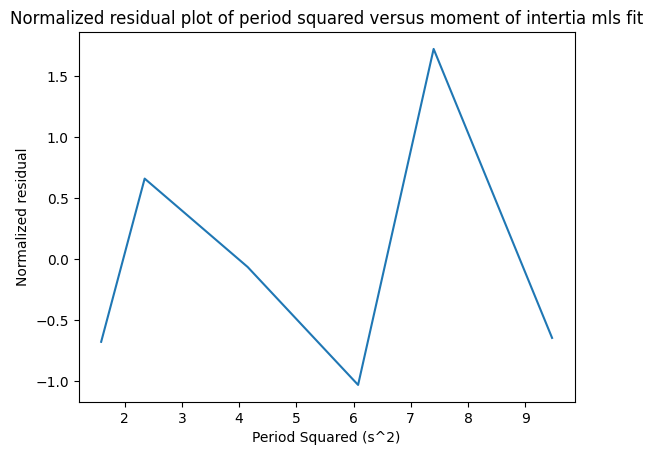

In [94]:
resid = [(Ilist[x] - calc[x])/ar[x] for x in range(6)]
plt.plot(t2, resid)
plt.title("Normalized residual plot of period squared versus moment of intertia mls fit")
plt.xlabel("Period Squared (s^2)")
plt.ylabel("Normalized residual")

In [99]:
print(Ilist)
print(calc)

[6.349999999999999e-06, 8.88e-06, 1.39e-05, 1.9e-05, 2.4100000000000003e-05, 2.9100000000000003e-05]
[np.float64(6.527875423155038e-06), np.float64(8.726090816586857e-06), np.float64(1.3932390432609587e-05), np.float64(1.9514700576456178e-05), np.float64(2.3332653628206186e-05), np.float64(2.9319898186632324e-05)]


In [102]:
o = np.array(Ilist)
e = np.array(calc)
chi2 = np.sum((weights*(o-e)**2))
print(chi2)
print(chi2/5)

5.366986935775934
1.0733973871551867
